<a href="https://colab.research.google.com/github/Priya-123-kp/Module---4-Assignment-5-Data-Preprocessing.ipynb/blob/main/Module_4_Assignment_5_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1 – Data Loading & Inspection

In [1]:
import pandas as pd
import numpy as np

1. Loaded dataset

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/refs/heads/main/diabetes.csv")

2.Display: head(), tail(), shape, columns, info(), dtypes

In [5]:
df.head()

,Unnamed: 0,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [7]:
df.tail()

,Unnamed: 0,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
1004,1004,194,454316,F,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,Y
1005,1005,195,4543,f,55.0,4.1,34.0,13.9,5.4,1.6,1.6,3.1,0.7,33.0,Y
1006,1006,249,48822,M,55.0,4.2,57.0,8.9,5.3,3.1,0.7,3.3,1.4,27.0,Y
1007,1007,88,21747,M,41.0,3.8,48.0,4.3,3.2,4.5,1.3,1.8,1.1,21.0,N
1008,1008,62,46059,M,55.0,7.0,56.0,9.1,3.7,1.9,0.7,2.3,0.9,27.0,Y


In [8]:
df.shape

(1009, 15)

In [9]:
df.columns

Index(['Unnamed: 0', 'ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c',
       'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1009 non-null   int64  
 1   ID          1009 non-null   int64  
 2   No_Pation   1009 non-null   int64  
 3   Gender      1006 non-null   object 
 4   AGE         1008 non-null   float64
 5   Urea        1008 non-null   float64
 6   Cr          1007 non-null   float64
 7   HbA1c       1006 non-null   float64
 8   Chol        1007 non-null   float64
 9   TG          1007 non-null   float64
 10  HDL         1008 non-null   float64
 11  LDL         1007 non-null   float64
 12  VLDL        1008 non-null   float64
 13  BMI         1009 non-null   float64
 14  CLASS       1009 non-null   object 
dtypes: float64(10), int64(3), object(2)
memory usage: 118.4+ KB


In [11]:
df.dtypes

,0
Unnamed: 0,int64
ID,int64
No_Pation,int64
Gender,object
AGE,float64
Urea,float64
Cr,float64
HbA1c,float64
Chol,float64
TG,float64


3.Identify numerical and categorical columns

In [12]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(list(numerical_cols))

print("Categorical Columns:")
print(list(categorical_cols))

Numerical Columns:
['Unnamed: 0', 'ID', 'No_Pation', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']
Categorical Columns:
['Gender', 'CLASS']


Task.2 Data Cleaning


Rename Columns: Update column names such as 'ID' to 'Visit_ID' and 'No_Pation' to
'Patient_ID' to make them more descriptive and clear

1. Rename Columns

In [13]:
df.rename(columns={
    'ID':'Visit_ID',
    'No_Pation':'Patient_ID'
}, inplace=True)

print(df.columns)

Index(['Unnamed: 0', 'Visit_ID', 'Patient_ID', 'Gender', 'AGE', 'Urea', 'Cr',
       'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')


2.Check Unique Values in Categorical Columns

Gender: F (Female) & M (Male),  
CLASS: N (No diabetes), P (Pre-diabetes), Y (Yes, Diabetes)

In [15]:
print("Gender Values:")
print(df['Gender'].unique())

print("CLASS Values:")
print(df['CLASS'].unique())

Gender Values:
['F' 'M' nan 'f']
CLASS Values:
['N' 'N ' 'P' 'Y' 'Y ']


Correct Unexpected Values

Standardize Gender

In [19]:

df['Gender'] = df['Gender'].replace({
    'f':'F',
    'female':'F',
    'Female':'F',
    'm':'M',
    'male':'M',
    'Male':'M'
})

Standardize CLASS

In [20]:
df['CLASS'] = df['CLASS'].replace({
    'n':'N',
    'p':'P',
    'y':'Y'
})

print(df['Gender'].unique())
print(df['CLASS'].unique())

['F' 'M' nan]
['N' 'N ' 'P' 'Y' 'Y ']


Statistical Summary of Numerical Columns

In [21]:
df.describe()

,Unnamed: 0,Visit_ID,Patient_ID,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1009.000000,1009.000000,1.009000e+03,1008.000000,1008.000000,1007.000000,1006.000000,1007.000000,1007.000000,1008.000000,1007.000000,1008.000000,1009.000000
mean,504.000000,338.166501,2.717468e+05,53.596230,5.132979,68.938431,8.281372,4.862483,2.346783,1.202728,2.611708,1.850496,29.573062
std,291.417513,239.479644,3.365681e+06,8.743882,2.930873,59.815673,2.534861,1.298665,1.396438,0.658038,1.115990,3.649872,4.953338
min,0.000000,1.000000,1.230000e+02,25.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,252.000000,126.000000,2.406400e+04,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,504.000000,294.000000,3.439900e+04,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,756.000000,547.000000,4.539100e+04,59.000000,5.700000,73.000000,10.175000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,1008.000000,800.000000,7.543566e+07,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


Generate statistical summary

In [25]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
summary = pd.DataFrame({
    'Mean': df[numerical_cols].mean(),
    'Median': df[numerical_cols].median(),
    'Min': df[numerical_cols].min(),
    'Max': df[numerical_cols].max(),
    'Standard Deviation': df[numerical_cols].std()
})

print(summary)

                     Mean   Median    Min          Max  Standard Deviation
Unnamed: 0     504.000000    504.0    0.0      1008.00        2.914175e+02
Visit_ID       338.166501    294.0    1.0       800.00        2.394796e+02
Patient_ID  271746.778989  34399.0  123.0  75435657.00        3.365681e+06
AGE             53.596230     55.0   25.0        79.00        8.743882e+00
Urea             5.132979      4.6    0.5        38.90        2.930873e+00
Cr              68.938431     60.0    6.0       800.00        5.981567e+01
HbA1c            8.281372      8.0    0.9        16.00        2.534861e+00
Chol             4.862483      4.8    0.0        10.30        1.298665e+00
TG               2.346783      2.0    0.3        13.80        1.396438e+00
HDL              1.202728      1.1    0.2         9.90        6.580379e-01
LDL              2.611708      2.5    0.3         9.90        1.115990e+00
VLDL             1.850496      0.9    0.1        35.00        3.649872e+00
BMI             29.573062

Box Plot of Numerical Columns-a box plot for all numerical columns in a single
graph to visualize their distribution, range, and outliers. Explain any visible trends or
outliers.

In [26]:
import matplotlib.pyplot as plt

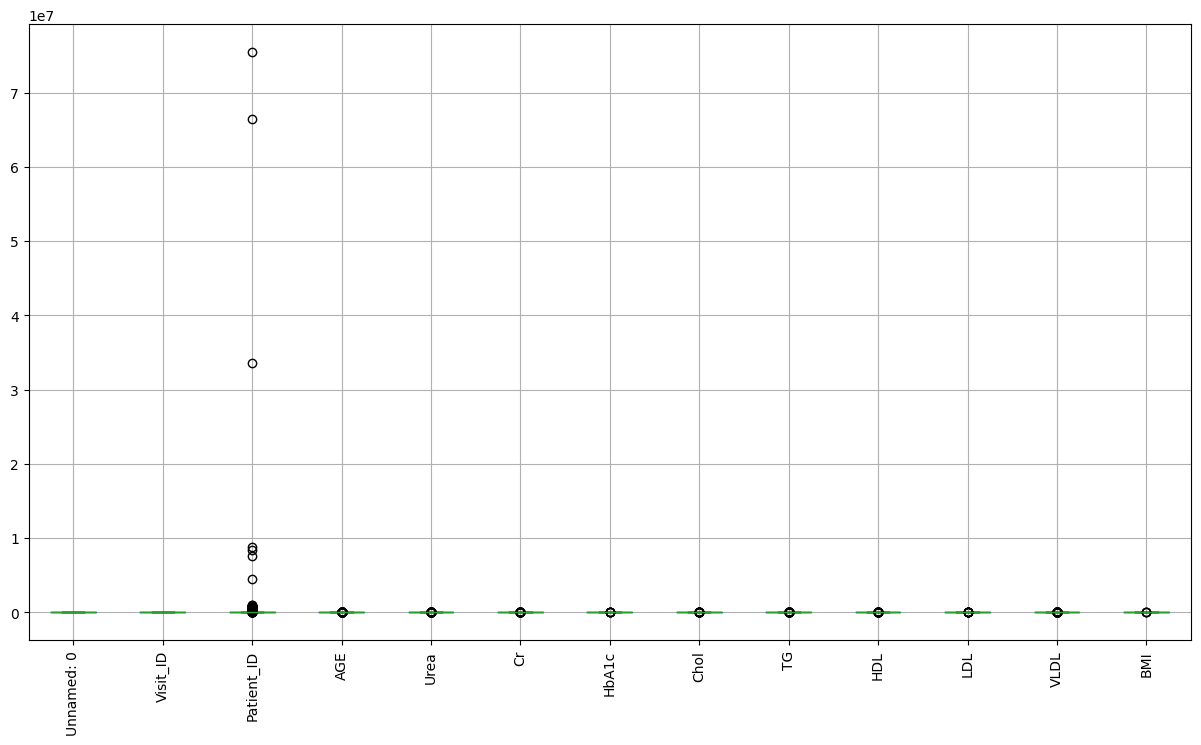

In [27]:
plt.figure(figsize=(15,8))
df.boxplot(rot=90)
plt.show()

Identify Missing (Null) Values: Determine the number of missing values in each column
and report which columns have null values.

In [29]:
df.isnull().sum()

,0
Unnamed: 0,0
Visit_ID,0
Patient_ID,0
Gender,3
AGE,1
Urea,1
Cr,2
HbA1c,3
Chol,2
TG,2


Impute Missing Values: Select an appropriate strategy (mean, median, or mode) to
impute missing values in the dataset. Justify the imputation technique for each column.
After imputation, verify that no missing values remain

In [31]:
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_3895/518003605.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Categorical Columns

In [33]:
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_3895/1077209983.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [34]:
df.isnull().sum()

,0
Unnamed: 0,0
Visit_ID,0
Patient_ID,0
Gender,0
AGE,0
Urea,0
Cr,0
HbA1c,0
Chol,0
TG,0


 Duplicate Handling: Identify duplicate rows and Remove duplicates

 Identify duplicate rows

In [35]:
df.duplicated().sum()

np.int64(0)

Remove duplicates

In [36]:
df.drop_duplicates(inplace=True)

In [37]:
df

,Unnamed: 0,Visit_ID,Patient_ID,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,1004,194,454316,F,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,Y
1005,1005,195,4543,F,55.0,4.1,34.0,13.9,5.4,1.6,1.6,3.1,0.7,33.0,Y
1006,1006,249,48822,M,55.0,4.2,57.0,8.9,5.3,3.1,0.7,3.3,1.4,27.0,Y
1007,1007,88,21747,M,41.0,3.8,48.0,4.3,3.2,4.5,1.3,1.8,1.1,21.0,N


Task 3-Outlier Handling



Retain Outliers: Retain outliers in the AGE, HbA1c, and BMI columns, explaining why
they should be preserved

In [40]:
columns_for_outlier_handling = ['AGE', 'HbA1c', 'BMI']

Filter Outliers

In [41]:
cr_limit = df['Cr'].quantile(0.995)

In [42]:
df = df[df['Cr'] <= cr_limit]

In [43]:
urea_limit = df['Urea'].quantile(0.999)

In [45]:
df = df[df['Urea'] <= urea_limit]

In [46]:
df

,Unnamed: 0,Visit_ID,Patient_ID,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,0,502,17975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,1,735,34221,M,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,2,420,47975,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,3,680,87656,F,50.0,4.7,46.0,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,4,504,34223,M,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,1004,194,454316,F,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,Y
1005,1005,195,4543,F,55.0,4.1,34.0,13.9,5.4,1.6,1.6,3.1,0.7,33.0,Y
1006,1006,249,48822,M,55.0,4.2,57.0,8.9,5.3,3.1,0.7,3.3,1.4,27.0,Y
1007,1007,88,21747,M,41.0,3.8,48.0,4.3,3.2,4.5,1.3,1.8,1.1,21.0,N


Remove Extreme Outliers

In [48]:
lipid_cols = ['Chol', 'TG', 'HDL', 'LDL', 'VLDL']
for col in lipid_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[(df[col]>=lower) &
            (df[col]<=upper)]

Task 4: Data Transformation

Feature Engineering: Apply Label Encoding or One-Hot Encoding to the categorical
column Gender to convert it into numeric format for model-building purposes.

In [51]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

In [52]:
df

,Unnamed: 0,Visit_ID,Patient_ID,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
1,1,735,34221,1,26.0,4.5,62.0,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
4,4,504,34223,1,33.0,7.1,46.0,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N
5,5,634,34224,0,45.0,2.3,24.0,4.0,2.9,1.0,1.0,1.5,0.4,21.0,N
6,6,721,34225,0,50.0,2.0,50.0,4.0,3.6,1.3,0.9,2.1,0.6,24.0,N
7,7,421,34227,1,48.0,4.7,47.0,4.0,2.9,0.8,0.9,1.6,0.4,24.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,1004,194,454316,0,57.0,4.1,70.0,9.3,5.3,3.3,1.0,1.4,1.3,29.0,Y
1005,1005,195,4543,0,55.0,4.1,34.0,13.9,5.4,1.6,1.6,3.1,0.7,33.0,Y
1006,1006,249,48822,1,55.0,4.2,57.0,8.9,5.3,3.1,0.7,3.3,1.4,27.0,Y
1007,1007,88,21747,1,41.0,3.8,48.0,4.3,3.2,4.5,1.3,1.8,1.1,21.0,N


Feature Scaling: Standardize or normalize the numerical columns that have varying
scales (e.g., Patients, AGE, BMI, Cr) to ensure consistent contribution in subsequent
analyses. Justify the scaling method used (standardization vs. normalization).

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Patient_ID','AGE','BMI','Cr']] = scaler.fit_transform(
df[['Patient_ID','AGE','BMI','Cr']]
)

In [54]:
df

,Unnamed: 0,Visit_ID,Patient_ID,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
1,1,735,-0.109643,1,-3.238335,4.5,-0.073737,4.9,3.7,1.4,1.1,2.1,0.6,-1.309081,N
4,4,504,-0.109638,1,-2.421431,7.1,-0.517724,4.9,4.9,1.0,0.8,2.0,0.4,-1.731816,N
5,5,634,-0.109636,0,-1.021023,2.3,-1.128206,4.0,2.9,1.0,1.0,1.5,0.4,-1.731816,N
6,6,721,-0.109634,0,-0.437520,2.0,-0.406727,4.0,3.6,1.3,0.9,2.1,0.6,-1.097713,N
7,7,421,-0.109629,1,-0.670921,4.7,-0.489975,4.0,2.9,0.8,0.9,1.6,0.4,-1.097713,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1004,1004,194,0.832796,0,0.379384,4.1,0.148256,9.3,5.3,3.3,1.0,1.4,1.3,-0.040876,Y
1005,1005,195,-0.176222,0,0.145983,4.1,-0.850714,13.9,5.4,1.6,1.6,3.1,0.7,0.804593,Y
1006,1006,249,-0.076887,1,0.145983,4.2,-0.212483,8.9,5.3,3.1,0.7,3.3,1.4,-0.463611,Y
1007,1007,88,-0.137627,1,-1.487826,3.8,-0.462226,4.3,3.2,4.5,1.3,1.8,1.1,-1.731816,N
